# 📱 Megaline Plan Revenue Analysis

## Introduction

Megaline offers two prepaid plans, **Surf** and **Ultimate**. This analysis examines customer behavior across calls, text messages, and mobile internet usage, reconstructs monthly revenue at the customer level, and uses statistical hypothesis testing to evaluate whether average revenue differs between the plans and between the NY-NJ area and other regions.

The dataset contains activity from approximately 500 customers during 2018.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)

In [2]:
users = pd.read_csv('../data/megaline_users.csv')
calls = pd.read_csv('../data/megaline_calls.csv')
messages = pd.read_csv('../data/megaline_messages.csv')
internet = pd.read_csv('../data/megaline_internet.csv')
plans = pd.read_csv('../data/megaline_plans.csv')

print('Users:', users.shape)
print('Calls:', calls.shape)
print('Messages:', messages.shape)
print('Internet:', internet.shape)
print('Plans:', plans.shape)

Users: (500, 8)
Calls: (137735, 4)
Messages: (76051, 3)
Internet: (104825, 4)
Plans: (2, 8)


### Initial inspection

In [3]:
for name, df in {'users': users, 'calls': calls, 'messages': messages, 'internet': internet, 'plans': plans}.items():
    print(f'\n{name.upper()}')
    print(df.head())
    print(df.dtypes)


USERS
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  
user_id        int64
first_name    object
last_name     object
age            int64
city          object
reg_date      object
plan          object
churn_date    object
dtype: object

CALLS
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145    

The five tables share identifiers that allow customer activity to be combined. Date fields are initially stored as strings and need conversion to `datetime`. Missing values in `churn_date` are meaningful: they indicate customers who were still active when the data was extracted.

## 2. Data Preparation

In [4]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
calls['call_date'] = pd.to_datetime(calls['call_date'])
messages['message_date'] = pd.to_datetime(messages['message_date'])
internet['session_date'] = pd.to_datetime(internet['session_date'])

calls['month'] = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month

# Megaline bills each individual call by rounding its duration up to the next minute.
calls['duration'] = np.ceil(calls['duration'])

In [5]:
quality_summary = pd.DataFrame({
    'rows': [len(users), len(calls), len(messages), len(internet), len(plans)],
    'duplicate_rows': [users.duplicated().sum(), calls.duplicated().sum(), messages.duplicated().sum(), internet.duplicated().sum(), plans.duplicated().sum()],
    'missing_values': [users.isna().sum().sum(), calls.isna().sum().sum(), messages.isna().sum().sum(), internet.isna().sum().sum(), plans.isna().sum().sum()]
}, index=['users', 'calls', 'messages', 'internet', 'plans'])
quality_summary

,rows,duplicate_rows,missing_values
users,500,0,466
calls,137735,0,0
messages,76051,0,0
internet,104825,0,0
plans,2,0,0


No duplicated records require removal. The missing values in the user table are concentrated in `churn_date` and are retained because they encode active subscriptions rather than data-quality errors. Internet sessions are not rounded individually; monthly usage is aggregated first, in accordance with the billing rules.

## 3. Monthly Customer Usage

In [6]:
calls_per_month = calls.groupby(['user_id', 'month']).agg(calls_count=('id', 'count')).reset_index()
minutes_per_month = calls.groupby(['user_id', 'month']).agg(minutes_used=('duration', 'sum')).reset_index()
messages_per_month = messages.groupby(['user_id', 'month']).agg(messages_count=('id', 'count')).reset_index()
internet_per_month = internet.groupby(['user_id', 'month']).agg(mb_used=('mb_used', 'sum')).reset_index()

monthly_usage = (
    calls_per_month
    .merge(minutes_per_month, on=['user_id', 'month'], how='outer')
    .merge(messages_per_month, on=['user_id', 'month'], how='outer')
    .merge(internet_per_month, on=['user_id', 'month'], how='outer')
)

usage_columns = ['calls_count', 'minutes_used', 'messages_count', 'mb_used']
monthly_usage[usage_columns] = monthly_usage[usage_columns].fillna(0)
monthly_usage = monthly_usage.merge(users[['user_id', 'plan']], on='user_id', how='left')
monthly_usage.head()

,user_id,month,calls_count,minutes_used,messages_count,mb_used,plan
0,1000,12,16.0,124.0,11.0,1901.47,ultimate
1,1001,8,27.0,182.0,30.0,6919.15,surf
2,1001,9,49.0,315.0,44.0,13314.82,surf
3,1001,10,65.0,393.0,53.0,22330.49,surf
4,1001,11,64.0,426.0,36.0,18504.30,surf


## 4. Monthly Revenue Calculation

In [7]:
def calculate_revenue(row):
    plan_info = plans.loc[plans['plan_name'] == row['plan']].iloc[0]
    extra_minutes = max(row['minutes_used'] - plan_info['minutes_included'], 0)
    extra_messages = max(row['messages_count'] - plan_info['messages_included'], 0)
    extra_gb = np.ceil(max(row['mb_used'] - plan_info['mb_per_month_included'], 0) / 1024)
    return (
        plan_info['usd_monthly_pay']
        + extra_minutes * plan_info['usd_per_minute']
        + extra_messages * plan_info['usd_per_message']
        + extra_gb * plan_info['usd_per_gb']
    )

monthly_usage['monthly_revenue'] = monthly_usage.apply(calculate_revenue, axis=1)
monthly_usage[['user_id', 'month', 'plan', 'monthly_revenue']].head()

,user_id,month,plan,monthly_revenue
0,1000,12,ultimate,70.00
1,1001,8,surf,20.00
2,1001,9,surf,20.00
3,1001,10,surf,90.09
4,1001,11,surf,60.00


## 5. Customer Behavior by Plan

### 5.1 Call Minutes

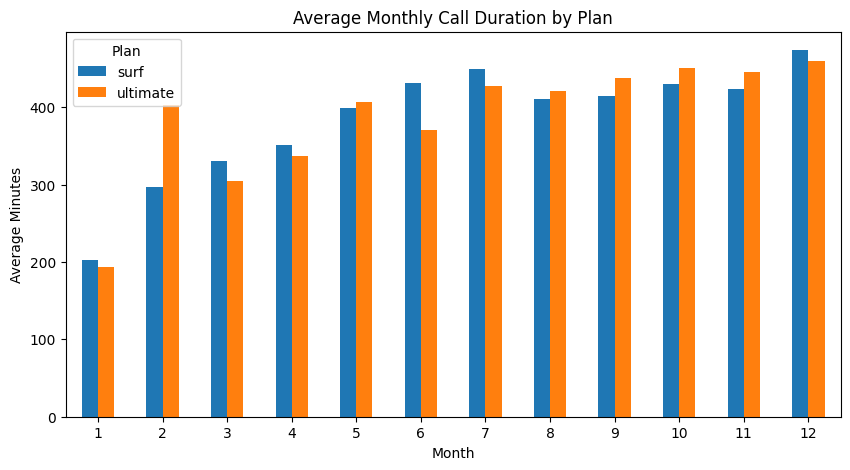

In [8]:
avg_minutes = monthly_usage.groupby(['month', 'plan'])['minutes_used'].mean().reset_index()
avg_minutes.pivot(index='month', columns='plan', values='minutes_used').plot(kind='bar', figsize=(10, 5))
plt.title('Average Monthly Call Duration by Plan')
plt.xlabel('Month'); plt.ylabel('Average Minutes'); plt.xticks(rotation=0); plt.legend(title='Plan'); plt.show()

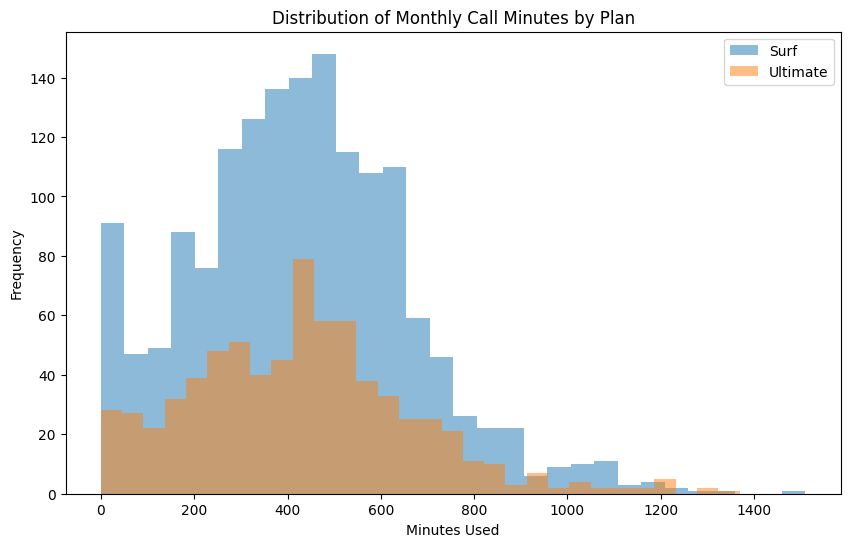

,mean,var,std
plan,,,
surf,428.749523,54968.279461,234.453150
ultimate,430.450000,57844.464812,240.508762


In [9]:
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    monthly_usage.loc[monthly_usage['plan'] == plan, 'minutes_used'].plot(kind='hist', bins=30, alpha=0.5, label=plan.title())
plt.title('Distribution of Monthly Call Minutes by Plan'); plt.xlabel('Minutes Used'); plt.ylabel('Frequency'); plt.legend(); plt.show()

minutes_stats = monthly_usage.groupby('plan')['minutes_used'].agg(['mean', 'var', 'std'])
minutes_stats

Call behavior is similar across the two plans. Their average monthly call usage and dispersion are close, and the distributions overlap substantially. Both plans also contain a smaller number of high-usage customers in the right tail.

### 5.2 Text Messages

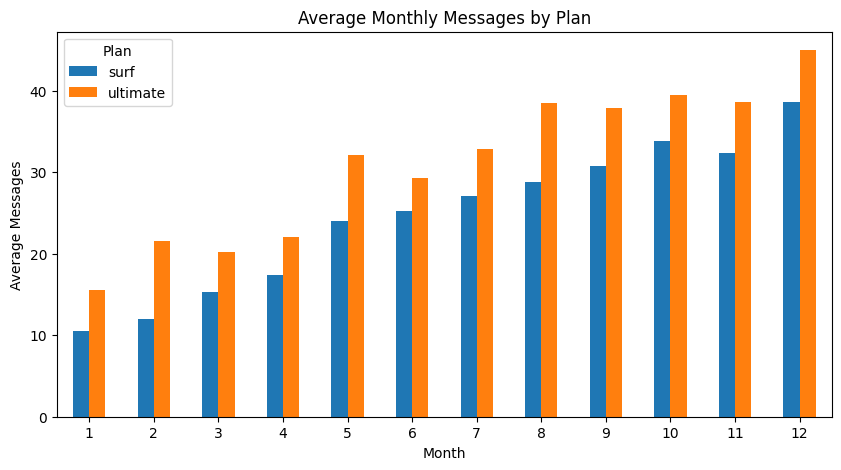

In [10]:
avg_messages = monthly_usage.groupby(['month', 'plan'])['messages_count'].mean().reset_index()
avg_messages.pivot(index='month', columns='plan', values='messages_count').plot(kind='bar', figsize=(10, 5))
plt.title('Average Monthly Messages by Plan'); plt.xlabel('Month'); plt.ylabel('Average Messages'); plt.xticks(rotation=0); plt.legend(title='Plan'); plt.show()

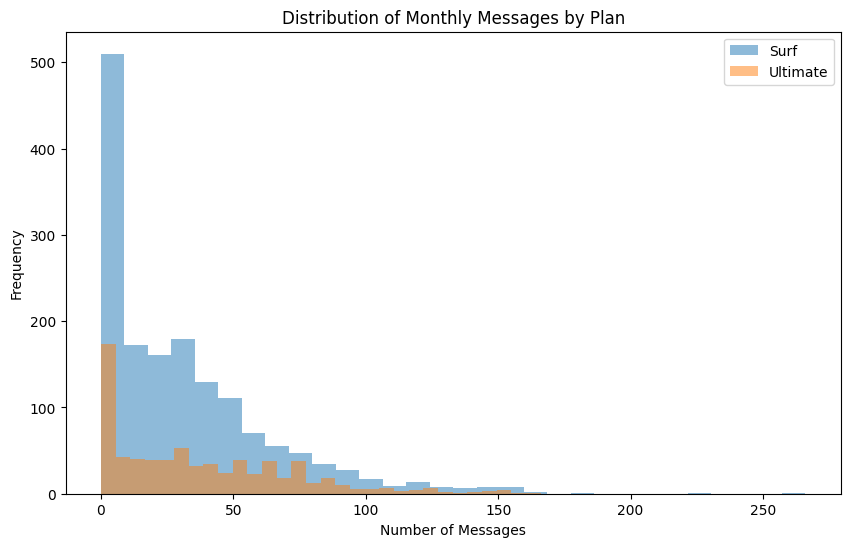

,mean,var,std
plan,,,
surf,31.159568,1126.724522,33.566717
ultimate,37.551389,1208.756744,34.767179


In [11]:
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    monthly_usage.loc[monthly_usage['plan'] == plan, 'messages_count'].plot(kind='hist', bins=30, alpha=0.5, label=plan.title())
plt.title('Distribution of Monthly Messages by Plan'); plt.xlabel('Number of Messages'); plt.ylabel('Frequency'); plt.legend(); plt.show()

messages_stats = monthly_usage.groupby('plan')['messages_count'].agg(['mean', 'var', 'std'])
messages_stats

Messaging activity is more dispersed than call usage, but the two plans still show substantial overlap. Ultimate customers send more messages on average, while both groups include customers with little or no monthly messaging activity and a smaller number of heavy users.

### 5.3 Internet Usage

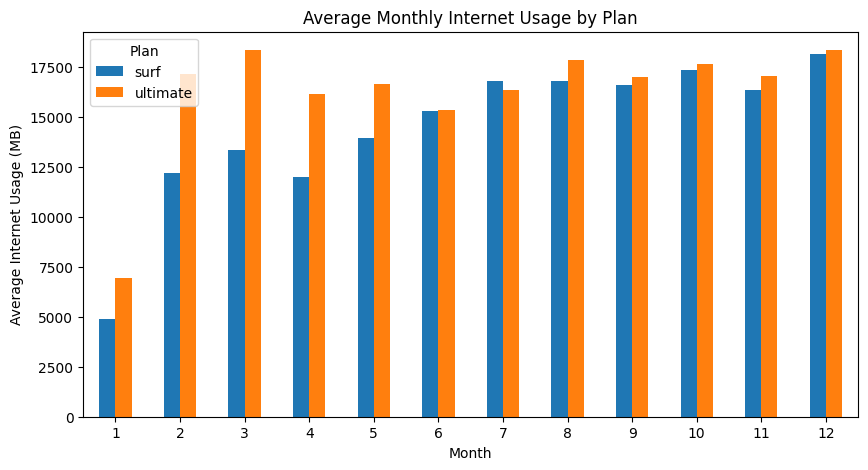

In [12]:
avg_internet = monthly_usage.groupby(['month', 'plan'])['mb_used'].mean().reset_index()
avg_internet.pivot(index='month', columns='plan', values='mb_used').plot(kind='bar', figsize=(10, 5))
plt.title('Average Monthly Internet Usage by Plan'); plt.xlabel('Month'); plt.ylabel('Average Internet Usage (MB)'); plt.xticks(rotation=0); plt.legend(title='Plan'); plt.show()

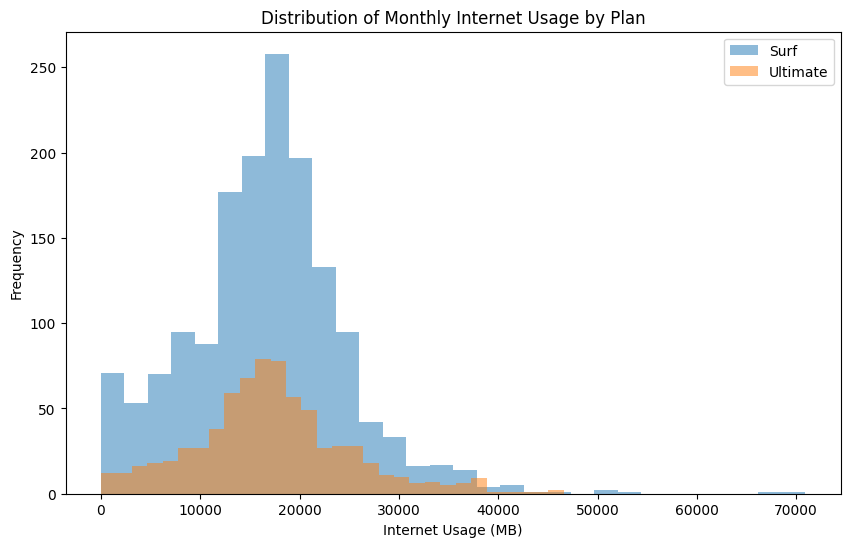

,mean,var,std
plan,,,
surf,16558.283490,6.421640e+07,8013.513327
ultimate,17214.699694,6.165229e+07,7851.897435


In [13]:
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    monthly_usage.loc[monthly_usage['plan'] == plan, 'mb_used'].plot(kind='hist', bins=30, alpha=0.5, label=plan.title())
plt.title('Distribution of Monthly Internet Usage by Plan'); plt.xlabel('Internet Usage (MB)'); plt.ylabel('Frequency'); plt.legend(); plt.show()

internet_stats = monthly_usage.groupby('plan')['mb_used'].agg(['mean', 'var', 'std'])
internet_stats

Internet consumption follows a broadly similar pattern for both plans. Ultimate customers use somewhat more data on average, but the distributions overlap strongly and both contain a right tail of heavier data users.

## 6. Revenue Analysis

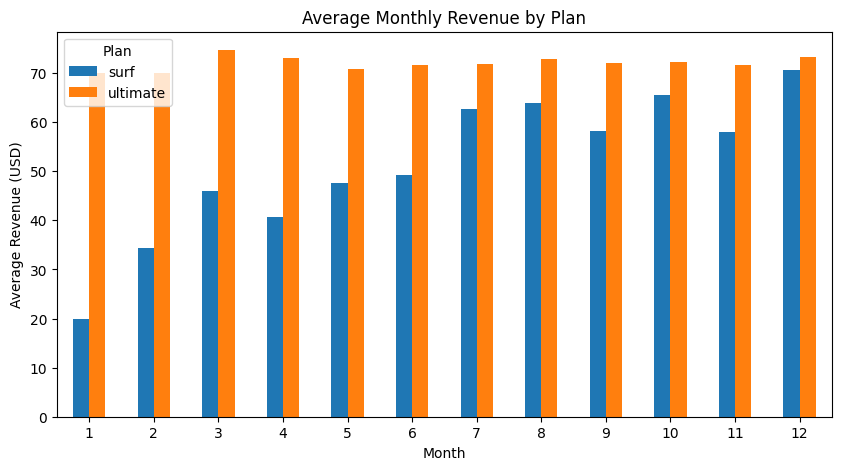

In [14]:
avg_revenue = monthly_usage.groupby(['month', 'plan'])['monthly_revenue'].mean().reset_index()
avg_revenue.pivot(index='month', columns='plan', values='monthly_revenue').plot(kind='bar', figsize=(10, 5))
plt.title('Average Monthly Revenue by Plan'); plt.xlabel('Month'); plt.ylabel('Average Revenue (USD)'); plt.xticks(rotation=0); plt.legend(title='Plan'); plt.show()

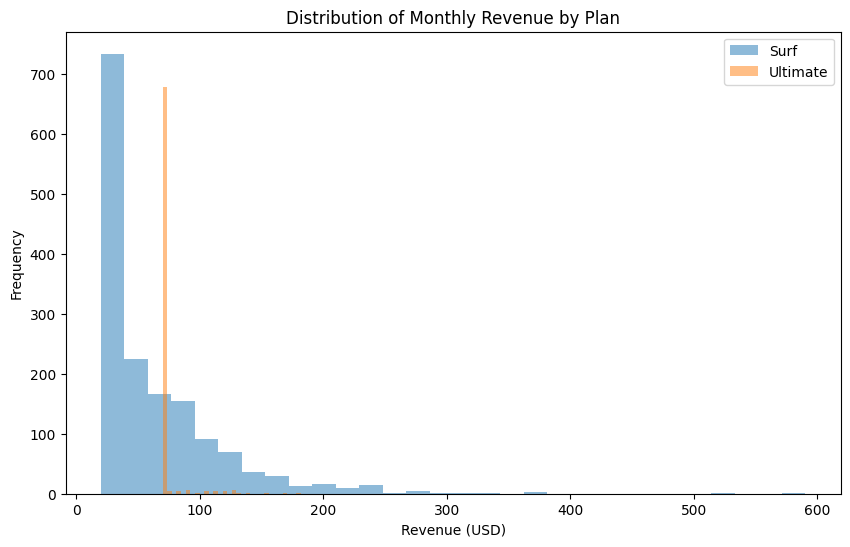

,mean,var,std
plan,,,
surf,60.706408,3067.835152,55.388042
ultimate,72.313889,129.848486,11.395108


In [15]:
plt.figure(figsize=(10, 6))
for plan in ['surf', 'ultimate']:
    monthly_usage.loc[monthly_usage['plan'] == plan, 'monthly_revenue'].plot(kind='hist', bins=30, alpha=0.5, label=plan.title())
plt.title('Distribution of Monthly Revenue by Plan'); plt.xlabel('Revenue (USD)'); plt.ylabel('Frequency'); plt.legend(); plt.show()

revenue_stats = monthly_usage.groupby('plan')['monthly_revenue'].agg(['mean', 'var', 'std'])
revenue_stats

Average monthly revenue is higher for Ultimate, while Surf revenue is considerably more variable. Ultimate revenue is concentrated near its fixed monthly fee, whereas Surf has a wider right tail because customers who exceed the smaller included allowances incur additional charges.

## 7. Statistical Hypothesis Testing

A significance level of **α = 0.05** is used. Because the comparisons involve the means of two independent groups and their variances are not assumed to be equal, Welch’s independent-samples t-test is applied.

### 7.1 Average Revenue: Surf vs. Ultimate

- **H₀:** The mean monthly revenue of Surf customers is equal to the mean monthly revenue of Ultimate customers.
- **H₁:** The mean monthly revenue of Surf customers is different from the mean monthly revenue of Ultimate customers.

In [16]:
surf_revenue = monthly_usage.loc[monthly_usage['plan'] == 'surf', 'monthly_revenue']
ultimate_revenue = monthly_usage.loc[monthly_usage['plan'] == 'ultimate', 'monthly_revenue']
alpha = 0.05
plan_test = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)
print(f'p-value: {plan_test.pvalue:.6g}')
print('Reject H0' if plan_test.pvalue < alpha else 'Fail to reject H0')

p-value: 3.17039e-15
Reject H0


The p-value is below 0.05, so the null hypothesis is rejected. The sample provides statistically significant evidence that average monthly revenue differs between Surf and Ultimate customers.

### 7.2 Average Revenue: NY-NJ vs. Other Regions

- **H₀:** The mean monthly revenue of customers in the NY-NJ area is equal to the mean monthly revenue of customers in other regions.
- **H₁:** The mean monthly revenue of customers in the NY-NJ area is different from the mean monthly revenue of customers in other regions.

In [17]:
monthly_usage = monthly_usage.merge(users[['user_id', 'city']], on='user_id', how='left')
monthly_usage['region'] = np.where(monthly_usage['city'].str.contains('NY-NJ', na=False), 'NY-NJ', 'Other')
ny_nj_revenue = monthly_usage.loc[monthly_usage['region'] == 'NY-NJ', 'monthly_revenue']
other_revenue = monthly_usage.loc[monthly_usage['region'] == 'Other', 'monthly_revenue']
region_test = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)
print(f'p-value: {region_test.pvalue:.6g}')
print('Reject H0' if region_test.pvalue < alpha else 'Fail to reject H0')

p-value: 0.0335256
Reject H0


The p-value is below 0.05, so the null hypothesis is rejected. Within this sample, average monthly revenue in the NY-NJ area differs significantly from average monthly revenue in the other regions.

## 8. General Conclusion

Customer usage patterns for calls and internet are broadly similar across Surf and Ultimate, while Ultimate customers send more messages on average. The clearest distinction appears in revenue: Ultimate produces a higher average monthly revenue, while Surf revenue is substantially more variable because overage charges play a larger role.

Welch’s t-tests indicate statistically significant differences in average monthly revenue both **between Surf and Ultimate** and **between NY-NJ customers and customers in other regions** at the 5% significance level.

These results describe the analyzed 2018 sample and should not be interpreted as causal evidence or automatically generalized beyond the available data.